# Lib

In [1]:
def write_ONT_preprocessing_mapping_script(script_fn, array_str):
    runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STRING
#SBATCH --nodes=1
#SBATCH --ntasks=32
#SBATCH --mem=50g
#SBATCH --time=24:00:00
#SBATCH --job-name=pp_ont
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

# module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
ml FastQC
ml minimap2
ml SAMtools
conda activate planb
which NanoPlot

# file listing all BeeStrong ids (bs_id) for parallel computing
barcode_file=$1
fastq_path=$2
minimap2_path=$3
idx_path=$4
idx_name=$5

# getting bs_id
barcode=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${barcode_file})

fastq=${fastq_path}${barcode}.fastq.gz
ls $fastq

echo "1. FastQC and NanoPlot"
# fastqc $fastq
NanoPlot -t 32 --fastq $fastq -o ${fastq_path}/${barcode}_nanoplot --no_static

echo "2. minimap2"
unmapped_prefix=${minimap2_path}${barcode}_${idx_name}_unmapped
mapped_prefix=${minimap2_path}${barcode}_${idx_name}_mapped

minimap2 -t 32 -a -x map-ont --secondary=no ${idx_path} $fastq > ${mapped_prefix}.sam # -a for outputing in .sam

echo "3. SAM to BAM"
samtools view -@ 32 -bS ${mapped_prefix}.sam | samtools sort -@ 32 -o ${mapped_prefix}.bam
rm -f ${mapped_prefix}.sam

# samtools sort & flagstat
echo "4. write flagstats and stats"
samtools flagstat ${mapped_prefix}.bam > ${mapped_prefix}.flagstat
samtools stats ${mapped_prefix}.bam | grep ^SN | cut -f 2- > ${mapped_prefix}.stats

echo "5. export unmapped reads"
samtools fastq -n -f 4 ${mapped_prefix}.bam > ${unmapped_prefix}.fastq # -f 4 includes only unmapped reads, -n preserved the sequence names

echo "6. delete and compress"
# rm -f ${mapped_prefix}.bam
gzip -f ${unmapped_prefix}.fastq 

echo DONE""".replace("ARRAY_STRING", array_str)
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

def write_Illumina_preprocessing_mapping_script(script_fn, array_str):
    runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STRING
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=60g
#SBATCH --time=12:00:00
#SBATCH --job-name=pp_mapping
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

# module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
ml SRA-Toolkit
ml cutadapt
ml Trimmomatic/0.39
ml FastQC
ml minimap2
ml SAMtools

# file listing all BeeStrong ids (bs_id) for parallel computing
bs_ids_file=$1
sra_path=$2
fastq_path=$3
sample_SRA_file=$4
minimap2_path=$5
idx_path=$6
idx_name=$7

adaptor_file=$EBROOTTRIMMOMATIC/adapters/TruSeq3-PE-2.fa
ls $adaptor_file

# getting bs_id
bs_id=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${bs_ids_file})

echo "1. find all SRA ids corresponding to the bs_id"
sra_ids=()
for sra in $(grep $bs_id $sample_SRA_file | cut -f 2); do
    sra_ids+=($sra)
    
    # download the SRA file on the go
    if [[ -d "$sra_path/$sra" || -f "$sra_path/$sra.sra" ]]; then
        echo "Skipping $sra: already downloaded"
    else
        echo "downloading $sra"
        prefetch -O $sra_path $sra
    fi
done

fastq_1=$fastq_path${bs_id}_1.fastq
fastq_2=$fastq_path${bs_id}_2.fastq
    
if [[ -f "$fastq_path${bs_id}_1.fastq" || -f "$fastq_path${bs_id}_2.fastq" ]]; then
    echo "2. fastq already dumped"
    ls $fastq_1
    ls $fastq_2
else
    echo "2. concatenate fastq from multiple SRA files"
    # initiate fastq files
    touch $fastq_1
    touch $fastq_2
    for sra in "${sra_ids[@]}"; do
        fasterq-dump $sra_path$sra -O $fastq_path
        # maybe a good idea to cancel the job here if sra.fastq not existing
        cat ${fastq_path}${sra}_1.fastq >> $fastq_1
        cat ${fastq_path}${sra}_2.fastq >> $fastq_2
        rm -f ${fastq_path}${sra}_1.fastq
        rm -f ${fastq_path}${sra}_2.fastq
    done
fi

echo "3. trim poly-G tails with cutadapt"
fastq_1_t=$fastq_path${bs_id}_1_cut.fastq
fastq_2_t=$fastq_path${bs_id}_2_cut.fastq

# cutadapt -a "G{10}" -A "G{10}" -m 50 -o $fastq_1_t -p $fastq_2_t $fastq_1 $fastq_2
cutadapt -j 8 -a "file:$adaptor_file" -A "file:$adaptor_file" -a "G{10}" -A "G{10}" -m 50 -o $fastq_1_t -p $fastq_2_t $fastq_1 $fastq_2

mv -f $fastq_1_t $fastq_1
mv -f $fastq_2_t $fastq_2

# echo "4. FastQC"
# fastqc $fastq_1 $fastq_2

echo "5. compress"
gzip -f $fastq_1 $fastq_2

echo "6. copy to home and clean"
rm  -f $fastq_1 $fastq_2

#### Mapping 

fastq_1=$fastq_path${bs_id}_1.fastq.gz
fastq_2=$fastq_path${bs_id}_2.fastq.gz
ls -lh $fastq_1
ls -lh $fastq_2

# echo "7. bowtie2"
# unmapped_prefix=${bowtie2_path}${bs_id}_${idx_name}_unmapped
# mapped_prefix=${bowtie2_path}${bs_id}_${idx_name}_mapped
# bowtie2 -x  ${idx_path}${idx_name} -p 8 -1 $fastq_1 -2 $fastq_2 -S ${mapped_prefix}.sam > ${bowtie2_path}${bs_id}_${idx_name}.out 2>&1

echo "7. minimap2"
unmapped_prefix=${minimap2_path}${bs_id}_${idx_name}_unmapped
mapped_prefix=${minimap2_path}${bs_id}_${idx_name}_mapped

minimap2 -t 16 -a -x sr --secondary=no ${idx_path} $fastq_1 $fastq_2 > ${mapped_prefix}.sam # -a for outputing in .sam # sr for short reads

echo "8. SAM to BAM"
samtools view -S -b ${mapped_prefix}.sam > ${mapped_prefix}.bam
rm -f ${mapped_prefix}.sam

# no need for the original fastq and sra --> we only keep the unmapped sequences
# rm -f $fastq_1
# rm -f $fastq_2
for sra in "${sra_ids[@]}"; do
    rm -rf $sra_path$sra
done

# samtools sort & flagstat (for comparison with bwa-mem2)
echo "9. sorting bam files and write flagstats"
samtools sort ${mapped_prefix}.bam > ${mapped_prefix}.sorted.bam
samtools flagstat ${mapped_prefix}.sorted.bam > ${mapped_prefix}.flagstat
samtools stats ${mapped_prefix}.sorted.bam | grep ^SN | cut -f 2- > ${mapped_prefix}.stats # nice to have this too 

# thibault stringent approach to remove bee reads
# Regenerate fastq files by removing all reads with mapped reads against at least one of the three A. mellifera genomes (for paired-end reads, I am conservative. If a read of the pair is mapped against one of the three genomes, I exclude that pair, i.e. -f 12)
echo "10. extracting unmapped reads"
samtools view -f 12 -b ${mapped_prefix}.sorted.bam > ${unmapped_prefix}.sorted.bam
samtools fastq -1 ${unmapped_prefix}.1.fastq -2 ${unmapped_prefix}.2.fastq -s ${unmapped_prefix}_singletons.fastq ${unmapped_prefix}.sorted.bam

echo "11. delete and compress"
rm -f ${mapped_prefix}.bam
rm -f ${mapped_prefix}.sorted.bam
rm -f ${unmapped_prefix}.sorted.bam
rm -f ${unmapped_prefix}_singletons.fastq
gzip -f ${unmapped_prefix}.1.fastq 
gzip -f ${unmapped_prefix}.2.fastq

echo DONE""".replace("ARRAY_STRING", array_str)
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

# start from the trimmed fastq.gz:

def write_Illumina_mapping_script(script_fn, array_str):
    runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STRING
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=60g
#SBATCH --time=12:00:00
#SBATCH --job-name=mapping
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

# module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
ml minimap2
ml SAMtools

# file listing all BeeStrong ids (bs_id) for parallel computing
bs_ids_file=$1
fastq_path=$2
minimap2_path=$3
idx_path=$4
idx_name=$5

# getting bs_id
bs_id=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${bs_ids_file})

#### Mapping 

fastq_1=$fastq_path${bs_id}_1.fastq.gz
fastq_2=$fastq_path${bs_id}_2.fastq.gz
ls -lh $fastq_1
ls -lh $fastq_2

echo "1. minimap2"
unmapped_prefix=${minimap2_path}${bs_id}_${idx_name}_unmapped
mapped_prefix=${minimap2_path}${bs_id}_${idx_name}_mapped

minimap2 -t 16 -a -x sr --secondary=no ${idx_path} $fastq_1 $fastq_2 > ${mapped_prefix}.sam # -a for outputing in .sam # sr for short reads

echo "8. SAM to BAM"
samtools view -S -b ${mapped_prefix}.sam > ${mapped_prefix}.bam
rm -f ${mapped_prefix}.sam

# samtools sort & flagstat (for comparison with bwa-mem2)
echo "9. sorting bam files and write flagstats"
samtools sort ${mapped_prefix}.bam > ${mapped_prefix}.sorted.bam
samtools flagstat ${mapped_prefix}.sorted.bam > ${mapped_prefix}.flagstat
samtools stats ${mapped_prefix}.sorted.bam | grep ^SN | cut -f 2- > ${mapped_prefix}.stats # nice to have this too 

# thibault stringent approach to remove bee reads
# Regenerate fastq files by removing all reads with mapped reads against at least one of the three A. mellifera genomes (for paired-end reads, I am conservative. If a read of the pair is mapped against one of the three genomes, I exclude that pair, i.e. -f 12)
echo "10. extracting unmapped reads"
samtools view -f 12 -b ${mapped_prefix}.sorted.bam > ${unmapped_prefix}.sorted.bam
samtools fastq -1 ${unmapped_prefix}.1.fastq -2 ${unmapped_prefix}.2.fastq -s ${unmapped_prefix}_singletons.fastq ${unmapped_prefix}.sorted.bam

echo "11. delete and compress"
rm -f ${mapped_prefix}.bam
# rm -f ${mapped_prefix}.sorted.bam # keep bam for a little bit
rm -f ${unmapped_prefix}.sorted.bam
rm -f ${unmapped_prefix}_singletons.fastq
gzip -f ${unmapped_prefix}.1.fastq 
gzip -f ${unmapped_prefix}.2.fastq

echo DONE""".replace("ARRAY_STRING", array_str)
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

def write_kraken2_script(kraken2_script_fn, array_str, read_pool, min_hit_grps, confidence):
    conf_str = str(confidence).replace('.', '')
    kraken2_runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STR
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=400g
#SBATCH --time=06:00:00
#SBATCH --job-name=kraken2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
which kraken2
which bracken

kdb_path=$1
kdb_name=$2
minimap2_path=$3
kraken2_path=$4
bracken_path=$5
barcode_file=$6

barcode=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${barcode_file})
fastq=${minimap2_path}${barcode}_bee3ref_unmapped.fastq.gz
ls $fastq

file_id=${barcode}_${kdb_name}_READPOOL_mhgMINHITGROUP_csCONFIDENCESTRING_sf1_rep1
echo $file_id

if [ ! -f ${kraken2_path}${file_id}.kraken2 ]; then
    echo '1. kraken2'
    kraken2 --threads 1 --db ${kdb_path}${kdb_name} --report-minimizer-data --minimum-hit-groups MINHITGROUP --confidence CONFIDENCESCORE --gzip-compressed --output ${kraken2_path}${file_id}.kraken2 --report ${kraken2_path}${file_id}.k2report ${fastq}
fi

echo '2. bracken'
bracken -d ${kdb_path}${kdb_name} -i ${kraken2_path}${file_id}.k2report -r 300 -l F -t 10 -o ${bracken_path}${file_id}_F.bracken -w ${bracken_path}${file_id}_F.breport # 300 is max available read length already precomputed
bracken -d ${kdb_path}${kdb_name} -i ${kraken2_path}${file_id}.k2report -r 300 -l G -t 10 -o ${bracken_path}${file_id}_G.bracken -w ${bracken_path}${file_id}_G.breport
bracken -d ${kdb_path}${kdb_name} -i ${kraken2_path}${file_id}.k2report -r 300 -l S -t 10 -o ${bracken_path}${file_id}_S.bracken -w ${bracken_path}${file_id}_S.breport

echo DONE""".replace('ARRAY_STR', array_str).replace('READPOOL', read_pool).replace('MINHITGROUP', min_hit_grps).replace('CONFIDENCESTRING', conf_str).replace('CONFIDENCESCORE', confidence)
    with open(kraken2_script_fn, 'w') as outf:
        outf.write(kraken2_runstr)

def write_myloasm_script(script_fn):
    runstr="""#!/bin/bash -l
#SBATCH --nodes=1
#SBATCH --ntasks=16
#SBATCH --mem=50g
#SBATCH --time=24:00:00
#SBATCH --job-name=myloasm
#SBATCH --output=%x_%j.out
#SBATCH --error=%x_%j.err

module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb

fastq_fn=$1
myloasm_path=$2

ls -lh ${fastq_fn}

myloasm ${fastq_fn} -o ${myloasm_path} -t 16

echo DONE"""
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

def write_contig_kraken2_script(kraken2_script_fn):
    kraken2_runstr="""#!/bin/bash -l
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=350g
#SBATCH --time=01:00:00
#SBATCH --job-name=contig_kraken2
#SBATCH --output=%x_%j.out
#SBATCH --error=%x_%j.err

module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
which kraken2

kdb_path=$1
kdb_name=$2
contig_fn=$3
kraken2_path=$4
out_name=$5

ls $contig_fn

echo '1. kraken2'
kraken2 --threads 8 --db ${kdb_path}${kdb_name} --report-minimizer-data --confidence 0.05 \
    --output ${kraken2_path}${out_name}.kraken2 --report ${kraken2_path}${out_name}.k2report ${contig_fn} --unclassified-out ${kraken2_path}${file_id}_uc.fastq # this force kraken2 to put reads filtered by mhg in kraken2 output
    
rm -f ${kraken2_path}${file_id}_uc.fastq

echo DONE"""
    with open(kraken2_script_fn, 'w') as outf:
        outf.write(kraken2_runstr)

def write_checkm2_script(script_fn):
    runstr="""#!/bin/bash -l
#SBATCH --nodes=1
#SBATCH --ntasks=40
#SBATCH --mem=50g
#SBATCH --time=24:00:00
#SBATCH --job-name=checkm2
#SBATCH --output=%x_%j.out
#SBATCH --error=%x_%j.err

module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate checkm2
conda env list

checkm2_bin=$1
contigs_dir=$2
checkm2_out=$3
checkm2_db=$4

${checkm2_bin} predict --input ${contigs_dir} -x fa -o ${checkm2_out} --threads 40 --database_path ${checkm2_db} --force

echo DONE"""
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

# 20 BeeStrong Samples Nanopore vs Illumina

In [2]:
import os
import gzip
import math
import random
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
from tqdm import tqdm as tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from bee_metagenomics_lib import (
    read_bs_ids_file, write_array_str, get_jobs_to_restart, parse_stats, parse_nanostats, parse_flagstats_ont
)

from ete3 import NCBITaxa
ncbi = NCBITaxa(dbfile="/cluster/raid/home/f80878961/data/NCBI_taxonomy/ncbi_taxonomy_202502/taxa.sqlite", update=False)


In [3]:
shared_data_path = '/cluster/raid/home/f80878961/data/'
script_path = "/cluster/raid/home/f80878961/scripts/tmp_scripts/"

working_path = '/cluster/raid/home/f80878961/nanopore/20_beestrong_samples/'


metadata_path = '{}00_metadata/'.format(working_path)
pp_path = '{}01_preprocessing/'.format(working_path)
bs_ids_file = '{}bs_ids.txt'.format(metadata_path)
idx_name = 'bee3ref'
idx_path = '{}minimap2_indexes/{}.mmi'.format(shared_data_path, idx_name)

# ont
fastq_path = '{}fastq/'.format(pp_path) 
minimap2_path =  '{}minimap2/'.format(pp_path)

# illumina 
sample_SRA_file = '{}sample_SRA.csv'.format(metadata_path)
sra_path = '{}sra/'.format(pp_path) 
fastq_sr_path = '{}fastq_sr/'.format(pp_path) 
minimap2_sr_path =  '{}minimap2_sr/'.format(pp_path)

#
assembly_path = '{}02_assembly/'.format(working_path)
myloasm_path = '{}myloasm/'.format(assembly_path)
spades_path = '{}spades/'.format(assembly_path)

# kraken2 taxonomic identification
kdb_path = '{}krakdb/'.format(shared_data_path)
kdb_name='corent'
contig_kraken2_path='{}contig_kraken2/'.format(assembly_path)


In [4]:
metadata_xlsx = '{}ES203_Overview_Sequencing_Runs_New_GridION.xlsx'.format(metadata_path)

metadata_df = pd.read_excel(metadata_xlsx, sheet_name='Sheet2', engine='openpyxl')
metadata_df.columns = metadata_df.iloc[14]
metadata_df = metadata_df.iloc[15:].reset_index(drop=True)

# list of beestrong sample ids for array job
bs_ids = [x.replace('-', '_') for x in metadata_df['Sample']]
with open(bs_ids_file, 'w') as outf:
    outf.write('\n'.join(bs_ids))

array_id2barcode, barcode2array_id = read_bs_ids_file(bs_ids_file)

# figure settings
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
tech_cmap = {
    'Nanopore': '#8da0cb', 
    'Illumina': '#fc8d62'
}

In [ ]:
# # merge files
# for r in tqdm(metadata_df.iterrows()):
#     barcode_nr = r[1]['#']
#     bs_id = r[1]['Sample'].replace('-', '_')
#     with open('{}{}.fastq.gz'.format(fastq_path, bs_id), 'wb') as outf:
#         for fn in glob.glob('{}fastq_pass/barcode{}/*.fastq.gz'.format(working_path, '%02d' % barcode_nr)):
#             with open(fn, 'rb') as inf:
#                 outf.write(inf.read())

## Preprocessing

### Nanopore

In [ ]:
step_name = 'pp_ont'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
]

completed_jobs_step_before = list(array_id2barcode)
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, completed_jobs_step_before, array_id2barcode, minimap2_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

In [ ]:
array_str = write_array_str(pp_jobs_to_run, min(len(pp_jobs_to_run), 10))
pp_script = '{}pp_ont.run'.format(script_path)
write_ONT_preprocessing_mapping_script(pp_script, array_str)
array_str

In [ ]:
pp_script, bs_ids_file, fastq_path, minimap2_path, idx_path, idx_name

In [ ]:
command = ['sbatch', pp_script, bs_ids_file, fastq_path, minimap2_path, idx_path, idx_name]
result = subprocess.run(command, cwd=minimap2_path, capture_output=False)

### Illumina (with minimap2) 

In [ ]:
step_name = 'pp_mapping'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_sr_path, idx_name), 
    '{}BSID_{}_unmapped.1.fastq.gz'.format(minimap2_sr_path, idx_name),
    '{}BSID_{}_unmapped.2.fastq.gz'.format(minimap2_sr_path, idx_name)
]
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, array_id2barcode, array_id2barcode, minimap2_sr_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

In [ ]:
array_str = write_array_str(pp_jobs_to_run, min(len(pp_jobs_to_run), 5))
pp_script = '{}pp_illumina.run'.format(script_path)
write_Illumina_preprocessing_mapping_script(pp_script, array_str)
array_str

In [ ]:
pp_script, bs_ids_file, sra_path, fastq_sr_path, sample_SRA_file, minimap2_sr_path, idx_path, idx_name

In [ ]:
command = ['sbatch', pp_script, bs_ids_file, sra_path, fastq_sr_path, sample_SRA_file, minimap2_sr_path, idx_path, idx_name]
result = subprocess.run(command, cwd=minimap2_sr_path, capture_output=False)

remap to get stats files...

In [ ]:
pp_completed_jobs

In [ ]:
array_str = write_array_str(pp_completed_jobs)
array_str = '2-20'
pp_script = '{}minimap2_illumina.run'.format(script_path)
write_Illumina_mapping_script(pp_script, array_str)
array_str

In [ ]:
pp_script, bs_ids_file, fastq_sr_path, minimap2_sr_path, idx_path, idx_name

In [ ]:
command = ['sbatch', pp_script, bs_ids_file, fastq_sr_path, minimap2_sr_path, idx_path, idx_name]
result = subprocess.run(command, cwd=minimap2_sr_path, capture_output=False)

### Mapping statistics

1. proporiton of bases mapping to honey bees, number of unmapped bases 

In [ ]:
columns = ['Colony', 'Technology', 'Bee Reads Fraction', 'Bee Bases Fraction', 'Non-bee Bases Number']
rows = []

# nanopore
for bc in bs_ids:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, 'Nanopore', res['reads mapped'] / res['sequences'], res['bases mapped'] / res['total length'], res['total length'] - res['bases mapped']))

# illumina (minimap2_sr_path)
for bc in bs_ids:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_sr_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, 'Illumina', res['reads mapped'] / res['sequences'], res['bases mapped'] / res['total length'], res['total length'] - res['bases mapped']))

flagstats_df = pd.DataFrame(rows, columns=columns)
flagstats_df

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(data=flagstats_df, x='Colony', y='Bee Bases Fraction', hue='Technology', palette=tech_cmap, legend=False, log_scale=False, ax=ax)
ax.yaxis.set_major_locator(MultipleLocator(0.1))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax = sns.violinplot(data=flagstats_df, x='Technology', y='Bee Bases Fraction', hue='Technology', palette=tech_cmap, legend=False, log_scale=False, ax=ax)
# ax.yaxis.set_major_locator(MultipleLocator(0.1))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(data=flagstats_df, x='Colony', y='Non-bee Bases Number', hue='Technology', palette=tech_cmap, legend=False, log_scale=False, ax=ax)
# ax.yaxis.set_major_locator(MultipleLocator(0.1))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax = sns.violinplot(data=flagstats_df, x='Technology', y='Non-bee Bases Number', hue='Technology', palette=tech_cmap, legend=False, log_scale=False, ax=ax)
# ax.yaxis.set_major_locator(MultipleLocator(0.1))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
columns = ['Colony', 'Technology', 'Category', 'Mean Read Lengh']
rows = []
for bc in bs_ids:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, 'Nanopore', 'Mapped', res['bases mapped'] / res['reads mapped']))
    rows.append((bc, 'Nanopore', 'Unmapped', (res['total length'] - res['bases mapped']) / res['reads unmapped']))

for bc in bs_ids:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_sr_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, 'Illumina', 'Mapped', res['bases mapped'] / res['reads mapped']))
    rows.append((bc, 'Illumina', 'Unmapped', (res['total length'] - res['bases mapped']) / res['reads unmapped']))

stats_df = pd.DataFrame(rows, columns=columns)
stats_df

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(data=stats_df[stats_df['Technology'] == 'Nanopore'], x='Colony', y='Mean Read Lengh', hue='Category', legend=True, log_scale=False, ax=ax)
# ax.yaxis.set_major_locator(MultipleLocator(0.1))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax = sns.boxplot(data=stats_df, x='Technology', y='Mean Read Lengh', hue='Category', legend=False, log_scale=False, ax=ax)
ax.yaxis.set_major_locator(MultipleLocator(50))  # ticks every 0.1
# ax.set_title('Proportion of ')
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

### Nanopore length filtering and subsampling

In [ ]:
def fq_reader(h):
    while True:
        h1 = h.readline()
        if not h1:
            return
        seq = h.readline()
        plus = h.readline()
        qual = h.readline()
        yield h1, seq, plus, qual

def bernoulli(p):
    return random.random() < p

def n50(lengths):
    lengths = np.sort(lengths)[::-1]           # sort descending
    cumsum = np.cumsum(lengths)                # cumulative sum
    half = cumsum[-1] / 2                      # half of total bases
    idx = np.searchsorted(cumsum, half)        # first index where cumsum >= half
    return lengths[idx]

def get_sampling_prob(median_read_length, sampling_prop, read_length, alpha):
    scaling_factor = (np.log(median_read_length) ** alpha)
    return min(1, sampling_prop * ((np.log(read_length) ** alpha) / scaling_factor))

In [ ]:
bs = 'BS18_0038'

In [ ]:
stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
res = parse_stats(stats_fn)

In [ ]:
sampling_prop = 1/2
alpha = 2
median_read_length = res['Median read length']
min_length = 500

In [ ]:
# infile
fastq_fn = '{}{}_{}_unmapped.fastq.gz'.format(minimap2_path, bs, idx_name)
nanostats_fn = '{}{}_{}_unmapped_nanoplot/NanoStats.txt'.format(minimap2_path, bs, idx_name)

# outfile
trim_fastq_fn = '{}{}_min{}.fastq.gz'.format(minimap2_path, bs, min_length)
long_fastq_fn = '{}{}_longer.fastq.gz'.format(minimap2_path, bs)

In [ ]:
res = parse_nanostats(nanostats_fn)
res

In [ ]:
read_lengths_longer = [0] * int(res['Number of reads'])
read_lengths_filter = [0] * int(res['Number of reads'])

with gzip.open(fastq_fn, 'rt') as inf:

    read_nr_longer = 0
    read_nr_filter = 0
    for h1, seq, plus, qual in fq_reader(inf):
        L = len(seq.rstrip())

        # sample read according to min threshold
        if L >= min_length:
            read_lengths_filter[read_nr_filter] = L
            read_nr_filter += 1
            
        # sample read according to length
        # p = get_sampling_prob(median_read_length, sampling_prop, L, alpha) 
        p = get_sampling_prob_lin(median_read_length, sampling_prop, L)
        if bernoulli(p):
            read_lengths_longer[read_nr_longer] = L
            read_nr_longer += 1

        
read_lengths_longer = np.array(read_lengths_longer[:read_nr_longer])
print(read_nr_longer / int(res['Number of reads']))
print(np.sum(read_lengths_longer) / int(res['Total bases']))
print(np.mean(read_lengths_longer))
print(np.median(read_lengths_longer))
print(n50(read_lengths_longer))
sns.histplot(read_lengths_longer, log_scale=True)

In [ ]:
n = 10000
sns.scatterplot(x=np.arange(10, n, 10), y=[get_sampling_prob(median_read_length, sampling_prop, L, alpha) for L in np.arange(10, n, 10)])

In [ ]:
read_lengths_filter = np.array(read_lengths_filter[:read_nr_filter])
print(read_nr_filter / int(res['Number of reads']))
print(np.sum(read_lengths_filter) / int(res['Total bases']))
print(np.mean(read_lengths_filter))
print(np.median(read_lengths_filter))
print(n50(read_lengths_filter))
sns.histplot(read_lengths_filter, log_scale=True)

### Illumina subsampling

--> aim is to have the number of base per samble between technology

In [ ]:
def fq_reader(h):
    while True:
        h1 = h.readline()
        if not h1:
            return
        seq = h.readline()
        plus = h.readline()
        qual = h.readline()
        yield h1, seq, plus, qual
        
def parse_flagstats(flagstats_fn):
    
    results = {
        'in_total': None, 
        'primary': None, 
        'secondary': None, 
        'supplementary': None, 
        'duplicates': None, 
        'primary_duplicates': None, 
        'mapped': None, 
        'primary_mapped': None,
        'with_itself_and_mate_mapped': None,
        'singletons': None
    }
        
    with open(flagstats_fn, "r") as inf:
        for l in inf:
            value = l.split()[0]
            stat = '_'.join(l.split('(')[0].split()[3:])
            if stat in results:
                results[stat] = float(value.split()[0].strip())

    return results

def get_unmapped_paired_read_nr(flagstat_res):
    return int((flagstat_res['primary'] - flagstat_res['with_itself_and_mate_mapped'] - 2 * flagstat_res['singletons']) / 2)

def subsample_fastq(fastq_fn, ss_fastq_fn, ss_reads):
    ss_fastq = gzip.open(ss_fastq_fn, 'wt')
    with gzip.open(fastq_fn, 'rt') as fastq:
        i = 0
        j = 0
        for h1, seq, plus, qual in fq_reader(fastq):
            if j >= ss_reads.size:
                break
            if i == ss_reads[j]:
                ss_fastq.write(h1)
                ss_fastq.write(seq)
                ss_fastq.write(plus)
                ss_fastq.write(qual)
                j+=1
            i+=1
    ss_fastq.close()

In [ ]:
np.random.seed(1234)

for bs in tqdm(bs_ids):

    if bs == 'BS18_0038':
        continue
        
    # get number of reads to subsample based on the number of bases we have with nanopore
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bs, idx_name)
    res = parse_stats(stats_fn)
    ss_read_nr = math.ceil((res['total length'] - res['bases mapped']) / 300)
    print(ss_read_nr)
        
    # get number of Illumina reads
    flagstat_res = parse_flagstats('{}{}_{}_mapped.flagstat'.format(minimap2_sr_path, bs, idx_name))
    read_nr = get_unmapped_paired_read_nr(flagstat_res)
    print(read_nr)
    
    # sample the reads
    ss_reads = np.array(np.sort(np.random.choice(np.arange(read_nr), size=ss_read_nr, replace=False)), dtype=int)
    
    fastq_1_fn = '{}{}_{}_unmapped.1.fastq.gz'.format(minimap2_sr_path, bs, idx_name)
    fastq_2_fn = '{}{}_{}_unmapped.2.fastq.gz'.format(minimap2_sr_path, bs, idx_name)
    ss_fastq_1_fn = '{}{}_{}_unmapped_ss.1.fastq.gz'.format(minimap2_sr_path, bs, idx_name)
    ss_fastq_2_fn = '{}{}_{}_unmapped_ss.2.fastq.gz'.format(minimap2_sr_path, bs, idx_name)
    
    subsample_fastq(fastq_1_fn, ss_fastq_1_fn, ss_reads)
    subsample_fastq(fastq_2_fn, ss_fastq_2_fn, ss_reads)

## Assembly

### Nanopore Assembly Myloasm

In [ ]:
assembly_script = '{}myloasm.run'.format(script_path)
write_myloasm_script(assembly_script)

In [ ]:
fastq_fn = '{}all_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
fastq_fn

In [ ]:
assembly_script, fastq_fn, myloasm_path

In [ ]:
command = ['sbatch', assembly_script, fastq_fn, myloasm_path]
result = subprocess.run(command, cwd=myloasm_path, capture_output=False)

In [ ]:
16893676 / 4

### Illumina Assembly MetaSpades

In [ ]:
def write_spades_script(script_fn):
    runstr="""#!/bin/bash -l
#SBATCH --nodes=1
#SBATCH --ntasks=16
#SBATCH --mem=250g
#SBATCH --time=24:00:00
#SBATCH --job-name=spades
#SBATCH --output=%x_%j.out
#SBATCH --error=%x_%j.err

module purge
modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
# conda activate planb
ml SPAdes


fastq_1=$1
fastq_2=$2
spades_path=$3
#spades_bin=$4

ls -lh ${fastq_1}
ls -lh ${fastq_2}

spades.py --meta -1 ${fastq_1} -2 ${fastq_2} -o ${spades_path} -t 16 -m 250

echo DONE"""
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

In [ ]:
spades_bin = '/cluster/raid/home/f80878961/bin/SPAdes-3.15.5-Linux/bin/spades.py'

In [ ]:
assembly_script = '{}spades.run'.format(script_path)
write_spades_script(assembly_script)

In [ ]:
fastq_1 = '{}all_{}_unmapped_ss.1.fastq.gz'.format(minimap2_sr_path, idx_name)
fastq_2 = '{}all_{}_unmapped_ss.2.fastq.gz'.format(minimap2_sr_path, idx_name)

In [ ]:
assembly_script, fastq_1, fastq_2, spades_path

In [ ]:
command = ['sbatch', assembly_script, fastq_1, fastq_2, spades_path]
result = subprocess.run(command, cwd=spades_path, capture_output=False)

### extract contigs / scaffolds

In [24]:
from Bio import SeqIO

from fasta extract all contigs larger than 300k bases 


In [29]:
scaffold_fa = '{}scaffolds.fasta'.format(spades_path)
scaffolds_dir = '{}scaffolds_dir/'.format(spades_path)

In [31]:
min_len = 100000
for record in SeqIO.parse(scaffold_fa, "fasta"):
    if len(record.seq) >= min_len:
        print(len(record.seq))
        SeqIO.write(record, '{}{}.fa'.format(scaffolds_dir, record.id), "fasta")

440054
371015
320700
191876
190575
148582
145817
143893
143019
138356
131335
130438
126258
116557
113861
111807
111592
106787
102747
101686


## Contig QC

### N50 and L50

In [65]:
def n50_l50(fasta, min_len=1000):
    lengths = sorted((len(rec.seq) for rec in SeqIO.parse(fasta, "fasta") if len(rec.seq) > min_len), reverse=True)
    total = sum(lengths)
    half = total / 2

    cum = 0
    for i, l in enumerate(lengths, 1):
        cum += l
        if cum >= half:
            return total, l, i  # N50, L50

In [66]:
# Illumina
contig_fa = '{}scaffolds.fasta'.format(spades_path)
total, N50, L50 = n50_l50(contig_fa)
print("Total =", total)
print("N50 =", N50)
print("L50 =", L50)

Total = 98594540
N50 = 5088
L50 = 3546


In [67]:
# Nanopore
contig_fa = '{}assembly_primary.fa'.format(myloasm_path)
total, N50, L50 = n50_l50(contig_fa)
print("Total =", total)
print("N50 =", N50)
print("L50 =", L50)

Total = 169491496
N50 = 17306
L50 = 1780


### Contig taxonomic classifiction with Kraken2

In [49]:
contig_kraken2_script = '{}contig_kraken2.run'.format(script_path)
write_contig_kraken2_script(contig_kraken2_script)

In [9]:
# contig_fn = '{}assembly_primary.fa'.format(myloasm_path)
# out_name = 'ont_myloasm'

contig_fn = '{}scaffolds.fasta'.format(spades_path)
out_name = 'sr_spades'

In [52]:
contig_kraken2_script, kdb_path, kdb_name, contig_fn, contig_kraken2_path, out_name

('/cluster/raid/home/f80878961/scripts/tmp_scripts/contig_kraken2.run',
 '/cluster/raid/home/f80878961/data/krakdb/',
 'corent',
 '/cluster/raid/home/f80878961/nanopore/20_beestrong_samples/02_assembly/spades/scaffolds.fasta',
 '/cluster/raid/home/f80878961/nanopore/20_beestrong_samples/02_assembly/contig_kraken2/',
 'sr_spades')

In [53]:
command = ['sbatch', contig_kraken2_script, kdb_path, kdb_name, contig_fn, contig_kraken2_path, out_name]
result = subprocess.run(command, cwd=contig_kraken2_path, capture_output=False)

Submitted batch job 1430848


In [29]:
out_name

'sr_spades'

In [26]:
k2_df = pd.read_table('{}{}.kraken2'.format(contig_kraken2_path, out_name), header=None)

In [30]:
k2_df[[0, 1, 2, 3]]

,0,1,2,3
0,C,NODE_1_length_440054_cov_8.657063,2070537,440054
1,U,NODE_2_length_371015_cov_9.367945,0,371015
2,U,NODE_3_length_320700_cov_7.589502,0,320700
3,C,NODE_4_length_191876_cov_8.532215,2134,191876
4,U,NODE_5_length_190575_cov_7.826895,0,190575
...,...,...,...,...
424091,C,NODE_424092_length_56_cov_3.000000,1267021,56
424092,U,NODE_424093_length_56_cov_2.000000,0,56
424093,U,NODE_424094_length_56_cov_2.000000,0,56
424094,U,NODE_424095_length_56_cov_2.000000,0,56


In [ ]:
k2_df[k2_df[1] == 'u104731ctg_len-1081811_circular-no_depth-18-2-1_duplicated-no']

### Checkm2

In [33]:
checkm2_script = '{}checkm2.run'.format(script_path)
write_checkm2_script(checkm2_script)

In [5]:
checkm2_bin = '/cluster/raid/home/f80878961/bin/checkm2/bin/checkm2'
# contigs_dir = '{}contigs_dir'.format(myloasm_path)
#checkm2_out = '{}checkm2/ont_myloasm'.format(assembly_path)

contigs_dir = '{}scaffolds_dir/'.format(spades_path)
checkm2_out = '{}checkm2/sr_spades'.format(assembly_path)

checkm2_db = '/cluster/raid/home/f80878961/bin/checkm2/CheckM2_database/uniref100.KO.1.dmnd'

In [6]:
checkm2_script, checkm2_bin, contigs_dir, checkm2_out, checkm2_db

NameError: name 'checkm2_script' is not defined

In [37]:
command = ['sbatch', checkm2_script, checkm2_bin, contigs_dir, checkm2_out, checkm2_db]
result = subprocess.run(command, cwd='{}checkm2/'.format(assembly_path), capture_output=False)

Submitted batch job 1430846


In [11]:
checkm2_df = pd.read_table('{}/quality_report.tsv'.format(checkm2_out))

In [8]:
checkm2_df.sort_values('Max_Contig_Length', ascending=False)

,Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Total_Contigs,Max_Contig_Length,Additional_Notes
10,NODE_1_length_440054_cov_8.657063,20.56,0.00,Neural Network (Specific Model),11,0.918,440054,337.944862,440054,0.38,399,1,440054,NaN
12,NODE_2_length_371015_cov_9.367945,17.90,0.00,Neural Network (Specific Model),11,0.894,371015,331.511976,371015,0.39,334,1,371015,NaN
13,NODE_3_length_320700_cov_7.589502,13.07,0.01,Neural Network (Specific Model),11,0.912,320700,346.039007,320700,0.39,282,1,320700,NaN
14,NODE_4_length_191876_cov_8.532215,15.19,0.00,Neural Network (Specific Model),4,0.901,191876,322.480447,191876,0.28,179,1,191876,NaN
15,NODE_5_length_190575_cov_7.826895,15.76,0.05,Neural Network (Specific Model),11,0.921,190575,321.890110,190575,0.39,182,1,190575,NaN
16,NODE_6_length_148582_cov_8.238718,7.99,0.00,Neural Network (Specific Model),11,0.927,148582,353.676923,148582,0.39,130,1,148582,NaN
17,NODE_7_length_145817_cov_7.977093,8.39,0.03,Neural Network (Specific Model),11,0.899,145817,288.375000,145817,0.40,152,1,145817,NaN
18,NODE_8_length_143893_cov_7.922176,5.52,0.00,Neural Network (Specific Model),11,0.899,143893,359.941667,143893,0.39,120,1,143893,NaN
19,NODE_9_length_143019_cov_8.876004,7.64,0.00,Neural Network (Specific Model),11,0.909,143019,358.429752,143019,0.40,121,1,143019,NaN
0,NODE_10_length_138356_cov_7.265609,8.37,0.00,Neural Network (Specific Model),11,0.907,138356,338.024194,138356,0.38,124,1,138356,NaN


In [31]:
k2_df = k2_df.rename(columns={1: 'Name', 2: 'TaxID'})[['Name', 'TaxID']]

In [32]:
k2_df['Taxon'] = ncbi.translate_to_names(k2_df['TaxID'])

In [33]:
pd.set_option('display.max_colwidth', None)

In [34]:
k2_df[:10]

,Name,TaxID,Taxon
0,NODE_1_length_440054_cov_8.657063,2070537,Commensalibacter melissae
1,NODE_2_length_371015_cov_9.367945,0,0
2,NODE_3_length_320700_cov_7.589502,0,0
3,NODE_4_length_191876_cov_8.532215,2134,Spiroplasma melliferum
4,NODE_5_length_190575_cov_7.826895,0,0
5,NODE_6_length_148582_cov_8.238718,0,0
6,NODE_7_length_145817_cov_7.977093,0,0
7,NODE_8_length_143893_cov_7.922176,0,0
8,NODE_9_length_143019_cov_8.876004,2,Bacteria
9,NODE_10_length_138356_cov_7.265609,0,0


In [35]:
checkm2_df[['Name', 'Completeness', 'Contamination', 'Coding_Density', 'Average_Gene_Length', 'Genome_Size', 'GC_Content', 'Total_Coding_Sequences']]

,Name,Completeness,Contamination,Coding_Density,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences
0,NODE_10_length_138356_cov_7.265609,8.37,0.00,0.907,338.024194,138356,0.38,124
1,NODE_11_length_131335_cov_7.200480,6.34,0.00,0.902,340.491379,131335,0.38,116
2,NODE_12_length_130438_cov_6.437243,8.75,0.03,0.897,314.596774,130438,0.30,124
3,NODE_13_length_126258_cov_8.248013,16.95,0.01,0.919,416.236559,126258,0.28,93
4,NODE_14_length_116557_cov_7.924070,13.41,0.10,0.908,254.172662,116557,0.28,139
5,NODE_15_length_113861_cov_25.384268,6.67,0.00,0.852,286.584071,113861,0.33,113
6,NODE_16_length_111807_cov_8.764165,7.30,0.00,0.911,309.118182,111807,0.41,110
7,NODE_17_length_111592_cov_70.862189,9.15,0.02,0.910,302.803571,111592,0.37,112
8,NODE_18_length_106787_cov_9.113968,5.52,0.01,0.891,296.934579,106787,0.42,107
9,NODE_19_length_102747_cov_9.079811,6.65,0.00,0.881,328.652174,102747,0.38,92


In [22]:
k2_df.merge(checkm2_df[['Name', 'Completeness', 'Contamination', 'Coding_Density', 'Average_Gene_Length', 'Genome_Size', 'GC_Content', 'Total_Coding_Sequences']], 
            on='Name')

,Name,TaxID,Taxon,Completeness,Contamination,Coding_Density,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences
0,NODE_1_length_440054_cov_8.657063,2070537,Commensalibacter melissae,20.56,0.00,0.918,337.944862,440054,0.38,399
1,NODE_2_length_371015_cov_9.367945,0,0,17.90,0.00,0.894,331.511976,371015,0.39,334
2,NODE_3_length_320700_cov_7.589502,0,0,13.07,0.01,0.912,346.039007,320700,0.39,282
3,NODE_4_length_191876_cov_8.532215,2134,Spiroplasma melliferum,15.19,0.00,0.901,322.480447,191876,0.28,179
4,NODE_5_length_190575_cov_7.826895,0,0,15.76,0.05,0.921,321.890110,190575,0.39,182
5,NODE_6_length_148582_cov_8.238718,0,0,7.99,0.00,0.927,353.676923,148582,0.39,130
6,NODE_7_length_145817_cov_7.977093,0,0,8.39,0.03,0.899,288.375000,145817,0.40,152
7,NODE_8_length_143893_cov_7.922176,0,0,5.52,0.00,0.899,359.941667,143893,0.39,120
8,NODE_9_length_143019_cov_8.876004,2,Bacteria,7.64,0.00,0.909,358.429752,143019,0.40,121
9,NODE_10_length_138356_cov_7.265609,0,0,8.37,0.00,0.907,338.024194,138356,0.38,124


In [73]:
contig_qc_df = k2_df.merge(checkm2_df[['Name', 'Completeness', 'Contamination', 'Coding_Density', 'Average_Gene_Length', 'Genome_Size', 'GC_Content', 'Total_Coding_Sequences']], 
            on='Name').sort_values('Genome_Size', ascending=False).reset_index(drop=True)

In [74]:
contig_qc_df

,Name,TaxID,Taxon,Completeness,Contamination,Coding_Density,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences
0,NODE_1_length_440054_cov_8.657063,2070537,Commensalibacter melissae,20.56,0.00,0.918,337.944862,440054,0.38,399
1,NODE_2_length_371015_cov_9.367945,0,0,17.90,0.00,0.894,331.511976,371015,0.39,334
2,NODE_3_length_320700_cov_7.589502,0,0,13.07,0.01,0.912,346.039007,320700,0.39,282
3,NODE_4_length_191876_cov_8.532215,2134,Spiroplasma melliferum,15.19,0.00,0.901,322.480447,191876,0.28,179
4,NODE_5_length_190575_cov_7.826895,0,0,15.76,0.05,0.921,321.890110,190575,0.39,182
5,NODE_6_length_148582_cov_8.238718,0,0,7.99,0.00,0.927,353.676923,148582,0.39,130
6,NODE_7_length_145817_cov_7.977093,0,0,8.39,0.03,0.899,288.375000,145817,0.40,152
7,NODE_8_length_143893_cov_7.922176,0,0,5.52,0.00,0.899,359.941667,143893,0.39,120
8,NODE_9_length_143019_cov_8.876004,2,Bacteria,7.64,0.00,0.909,358.429752,143019,0.40,121
9,NODE_10_length_138356_cov_7.265609,0,0,8.37,0.00,0.907,338.024194,138356,0.38,124


# ES236 EXP06

In [ ]:
import os
import glob
import subprocess
import pandas as pd
from tqdm import tqdm as tqdm

from bee_metagenomics_lib import (
    read_bs_ids_file, write_array_str, get_jobs_to_restart, 
    parse_flagstats_ont,
    parse_nanostats,
    parse_stats
)

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
shared_data_path = '/cluster/raid/home/f80878961/data/'
script_path = "/cluster/raid/home/f80878961/scripts/tmp_scripts/"

working_path = '/cluster/raid/home/f80878961/nanopore/ES236_EXP06/'
barcode_fn = '{}barcodes.txt'.format(working_path)

fastq_path = '{}fastq/'.format(working_path)
minimap2_path =  '{}minimap2/'.format(working_path)
idx_name = 'bee3ref'
idx_path = '{}minimap2_indexes/{}.mmi'.format(shared_data_path, idx_name)

kraken2_path = '{}kraken2/'.format(working_path)
bracken_path = '{}bracken/'.format(working_path)
kdb_path = '{}krakdb/'.format(shared_data_path)

In [ ]:
# # simple cat should be faster...
# for bc in tqdm(glob.glob('{}fastq_pass/*'.format(working_path))):
#     bc = bc.split('/')[-1]
#     if bc == 'unclassified':
#         continue
#     with open('{}{}.fastq.gz'.format(fastq_path, bc), 'wb') as outf:
#         for fn in glob.glob('{}fastq_pass/{}/*.fastq.gz'.format(working_path, bc)):
#             with open(fn, 'rb') as inf:
#                 outf.write(inf.read())

In [ ]:
columns = ['Barcode', 'Sample', 'Bee Nr', 'Protocol']
rows = []
with open('{}sample-id.txt'.format(working_path), 'r') as inf:
    for l in inf:
        if l.startswith('BC'):
            bc, sample = l.rstrip().split(':')
            bee_nr = sample.split('_')[0]
            protocol = '_'.join(sample.split('_')[2:])
            rows.append((bc[2:], sample, bee_nr, protocol))
metadata_df = pd.DataFrame(rows, columns=columns)
metadata_df

In [ ]:
# metadata_df['Barcode'].to_csv(barcode_fn, header=False, index=False)

array_id2barcode, barcode2array_id = read_bs_ids_file(barcode_fn)
array_id2barcode

### preprocessing

In [ ]:
array_id2barcode, barcode2array_id = read_bs_ids_file(barcode_fn)
array_id2barcode

In [ ]:
step_name = 'pp_ont'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
]

completed_jobs_step_before = list(array_id2barcode)[:-1]
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, completed_jobs_step_before, array_id2barcode, minimap2_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

In [ ]:
# most efficient is actually to run things in home 
array_str = write_array_str(pp_jobs_to_run, min(len(pp_jobs_to_run), 7))
pp_script = '{}pp_ont.run'.format(script_path)
write_ONT_preprocessing_mapping_script(pp_script, array_str)
array_str

In [ ]:
barcode_fn, fastq_path, minimap2_path, idx_path, idx_name

In [ ]:
command = ['sbatch', pp_script, barcode_fn, fastq_path, minimap2_path, idx_path, idx_name]
result = subprocess.run(command, cwd=minimap2_path, capture_output=False)

### basic stats and proportion of bee reads


parse nanoplot reports to answer how much data and how long are the seqeuence? and of what quality

how much bee reads?

In [ ]:
  

x_order = ['10_BioR2_DNA', '30_BioR2_DNA', '50_BioR2_DNA', '10_BioR1_cDNA_Lunascript', '30_BioR1_cDNA_Lunascript', '50_BioR1_cDNA_Lunascript', 
           '10_BioR1_cDNA_MaximaH', '30_BioR1_cDNA_MaximaH', '50_BioR1_cDNA_MaximaH']

cmap = {
    '10_BioR2_DNA': '#0173b2',
    '30_BioR2_DNA': '#0173b2',
    '50_BioR2_DNA': '#0173b2',
    '10_BioR1_cDNA_Lunascript': '#0e7256',
    '30_BioR1_cDNA_Lunascript': '#0e7256',
    '50_BioR1_cDNA_Lunascript': '#0e7256',
    '10_BioR1_cDNA_MaximaH': '#58bea1',
    '30_BioR1_cDNA_MaximaH': '#58bea1',
    '50_BioR1_cDNA_MaximaH': '#58bea1'
}

In [ ]:
columns = ['Barcode', 'Mean read length', 'Mean read quality', 'Median read length', 'Median read quality', 'Number of reads', 'Read length N50', 'STDEV read length', 'Total bases']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    nanostats_fn = '{}barcode{}_nanoplot/NanoStats.txt'.format(fastq_path, bc)
    if not os.path.exists(nanostats_fn): continue
    res = parse_nanostats(nanostats_fn)
    rows.append(([bc] + list(res.values())))
nanostats_df = metadata_df.merge(pd.DataFrame(rows, columns=columns), on='Barcode')
nanostats_df

In [ ]:
for stat in columns[1:]:

    plt.figure(figsize=(6, 6))
    ax = sns.barplot(data=nanostats_df, x='Sample', y=stat, hue='Sample', order = x_order, palette=cmap, legend=False, log_scale=False)
    plt.xticks(rotation=90)
    
    # # Manually add the legend to the right side
    # handles, labels = ax.get_legend_handles_labels()
    # plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(None)
    plt.tight_layout()
    plt.show()

In [ ]:
parse_stats(stats_fn):

In [ ]:
bc = 15
stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)

In [ ]:
parse_stats(stats_fn)

In [ ]:
parse_flagstats_ont('{}{}_{}_mapped.flagstat'.format(minimap2_path, bc, idx_name))

In [ ]:
columns = ['Barcode', 'Bee Reads Fraction', 'Bee Bases Fraction']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, res['reads mapped'] / res['sequences'], res['bases mapped'] / res['total length']))
flagstats_df = metadata_df.merge(pd.DataFrame(rows, columns=columns), on='Barcode')
flagstats_df

In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.barplot(data=flagstats_df, x='Sample', y='Bee Reads Fraction', hue='Sample', order = x_order, palette=cmap, legend=False, log_scale=False)
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.barplot(data=flagstats_df, x='Sample', y='Bee Bases Fraction', hue='Sample', order = x_order, palette=cmap, legend=False, log_scale=False)
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [ ]:
columns = ['Barcode', 'Category', 'Mean Read Lengh']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)

    # for mapped reads
    rows.append((bc, 'Mapped', res['bases mapped'] / res['reads mapped']))

    # for unmapped
    rows.append((bc, 'Unmapped', (res['total length'] - res['bases mapped']) / res['reads unmapped']))

stats_df = metadata_df.merge(pd.DataFrame(rows, columns=columns), on='Barcode')
stats_df

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=stats_df, x='Sample', y='Mean Read Lengh', hue='Category', order = x_order, legend=True, log_scale=False)
plt.xticks(rotation=90)

# # Manually add the legend to the right side
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

very interesting that we have much less read mapping 

- due to minimap?
- is it due to short reads? what if I filter by readlength? (.bam --> filter alignments)
- is it due to bioreba bag?

also same for DNA and cDNA hmm

### taxonomic profiling with Kraken2

In [ ]:
kdb_name = 'corent'
read_pool = 'nonbee'
mhg = '2'
cs = '0.05'
# cs = '0.25'
# cs = '0.50'

In [ ]:
# get finished pp_ont jobs
step_name = 'pp_ont'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
]

completed_jobs_step_before = list(array_id2barcode)[:-1]
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, completed_jobs_step_before, array_id2barcode, minimap2_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

In [ ]:
k2_jobs_to_run = pp_completed_jobs

In [ ]:
step_name = 'kraken2'

k2_exp_files = [
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1.kraken2'.format(kraken2_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1.k2report'.format(kraken2_path, kdb_name, read_pool, mhg, str(cs).replace('.', ''))]
brack_exp_files = [
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_S.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_S.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_F.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_F.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_G.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_G.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
]

k2_jobs_to_run, k2_completed_jobs = get_jobs_to_restart(step_name, pp_completed_jobs, array_id2barcode, kraken2_path, k2_exp_files + brack_exp_files)
k2_jobs_to_run, k2_completed_jobs

In [ ]:
# most efficient is actually to run things in home 
array_str = write_array_str(k2_jobs_to_run, min(len(k2_jobs_to_run), 2))
kraken2_script = '{}kraken2.run'.format(script_path)
write_kraken2_script(kraken2_script, array_str, read_pool, mhg, cs)
array_str

In [ ]:
kdb_path, kdb_name, minimap2_path, kraken2_path, bracken_path, barcode_fn

In [ ]:
command = ['sbatch', kraken2_script, kdb_path, kdb_name, minimap2_path, kraken2_path, bracken_path, barcode_fn]
result = subprocess.run(command, cwd=kraken2_path, capture_output=False)

# ES219 EXP04

these are DNA agripol samples

In [14]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bee_metagenomics_lib import (
    read_bs_ids_file, write_array_str, get_jobs_to_restart, parse_stats, parse_nanostats, parse_flagstats_ont
)

from ete3 import NCBITaxa
ncbi = NCBITaxa(dbfile="/cluster/raid/home/f80878961/data/NCBI_taxonomy/ncbi_taxonomy_202502/taxa.sqlite", update=False)

In [3]:
shared_data_path = '/cluster/raid/home/f80878961/data/'
script_path = "/cluster/raid/home/f80878961/scripts/tmp_scripts/"
working_path = '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/'

metadata_path = '{}00_metadata/'.format(working_path)
pp_path = '{}01_preprocessing/'.format(working_path)

fastq_path = '{}fastq/'.format(pp_path) 
minimap2_path =  '{}minimap2/'.format(pp_path)
idx_name = 'bee3ref'
idx_path = '{}minimap2_indexes/{}.mmi'.format(shared_data_path, idx_name)

taxonomic_classif_path = '{}02_taxonomic_classif/'.format(working_path)
kraken2_path = '{}kraken2/'.format(taxonomic_classif_path)
bracken_path = '{}bracken/'.format(taxonomic_classif_path)
kdb_path = '{}krakdb/'.format(shared_data_path)
kdb_name = 'corent'

assembly_path = '{}03_assembly/'.format(working_path)
myloasm_path = '{}myloasm/'.format(assembly_path)
contig_kraken2_path='{}contig_kraken2/'.format(assembly_path)
checkm2_path = '{}checkm2/'.format(assembly_path)

sns.set_style('whitegrid')

In [4]:
metadata_xlsx = '{}ES219_EXP04_Overview_Sequencing_Runs_New_GridION.xlsx'.format(metadata_path)

metadata_df = pd.read_excel(metadata_xlsx, sheet_name='Sheet2', engine='openpyxl')
metadata_df.columns = metadata_df.iloc[14]
metadata_df = metadata_df.iloc[15:].reset_index(drop=True)

# list of beestrong sample ids for array job
bs_ids = [x.replace('-', '_') for x in metadata_df['Sample']]
bs_ids_file = '{}bs_ids.txt'.format(metadata_path)
# with open(bs_ids_file, 'w') as outf:
#     outf.write('\n'.join(bs_ids))
array_id2barcode, barcode2array_id = read_bs_ids_file(bs_ids_file)
metadata_df

14,#,Sample,Barcode,Run ID,Flowcell ID
0,1,V3R08C052021,22,20250730_B_ES219_EXP04_SITEM_P2,PBE30650
1,2,V1R16C092019,23,20250730_B_ES219_EXP04_SITEM_P2,PBE30650
2,3,V3R15C052020,24,20250730_B_ES219_EXP04_SITEM_P2,PBE30650


In [6]:
# # merge files
# for r in metadata_df.iterrows():
#     barcode_nr = r[1]['Barcode']
#     fastq_fn = '{}{}.fastq.gz'.format(fastq_path, r[1]['Sample'])
# 
#     print(barcode_nr, fastq_fn)
#     with open(fastq_fn, 'wb') as outf:
#         for fn in glob.glob('{}data/fastq_pass/barcode{}/*.fastq.gz'.format(working_path, '%02d' % barcode_nr)):
#             with open(fn, 'rb') as inf:
#                 outf.write(inf.read())

## Preprocessing

In [5]:
step_name = 'pp_ont'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
]

completed_jobs_step_before = list(array_id2barcode)
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, completed_jobs_step_before, array_id2barcode, minimap2_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

([], [1, 2, 3])

In [6]:
array_id2barcode

{1: 'V3R08C052021', 2: 'V1R16C092019', 3: 'V3R15C052020'}

In [7]:
array_str = write_array_str(pp_jobs_to_run, min(len(pp_jobs_to_run), 10))
pp_script = '{}pp_ont.run'.format(script_path)
write_ONT_preprocessing_mapping_script(pp_script, array_str)
array_str

IndexError: list index out of range

In [30]:
pp_script, bs_ids_file, fastq_path, minimap2_path, idx_path, idx_name

('/cluster/raid/home/f80878961/scripts/tmp_scripts/pp_ont.run',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/00_metadata/bs_ids.txt',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/01_preprocessing/fastq/',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/01_preprocessing/minimap2/',
 '/cluster/raid/home/f80878961/data/minimap2_indexes/bee3ref.mmi',
 'bee3ref')

In [31]:
command = ['sbatch', pp_script, bs_ids_file, fastq_path, minimap2_path, idx_path, idx_name]
result = subprocess.run(command, cwd=minimap2_path, capture_output=False)

Submitted batch job 1430968


### basic stats and proportion of bee reads


In [8]:
x_order = ['V3R08C052021', 'V3R15C052020', 'V1R16C092019']

In [11]:
columns = ['Barcode', 'Mean read length', 'Mean read quality', 'Median read length', 'Median read quality', 'Number of reads', 'Read length N50', 'STDEV read length', 'Total bases']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    nanostats_fn = '{}{}_nanoplot/NanoStats.txt'.format(fastq_path, bc)
    if not os.path.exists(nanostats_fn): continue
    res = parse_nanostats(nanostats_fn)
    rows.append(([bc] + list(res.values())))
nanostats_df = pd.DataFrame(rows, columns=columns)
nanostats_df

,Barcode,Mean read length,Mean read quality,Median read length,Median read quality,Number of reads,Read length N50,STDEV read length,Total bases
0,V3R08C052021,1886.5,17.2,482.0,19.2,3160695.0,7257.0,4075.4,5.962727e+09
1,V1R16C092019,682.9,17.8,517.0,19.7,72266768.0,881.0,608.7,4.935308e+10
2,V3R15C052020,1573.9,17.2,411.0,19.1,2701309.0,6373.0,3589.5,4.251527e+09


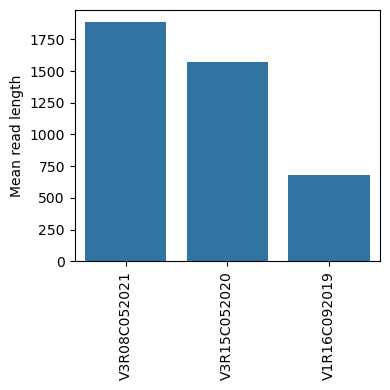

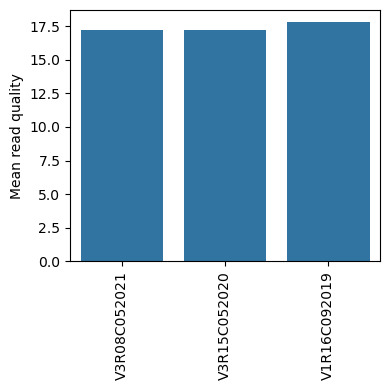

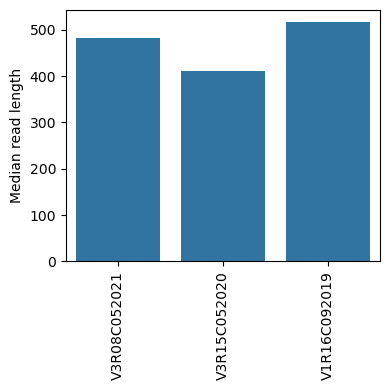

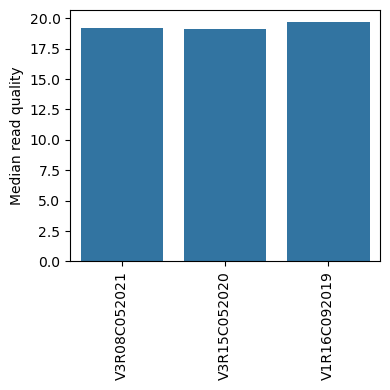

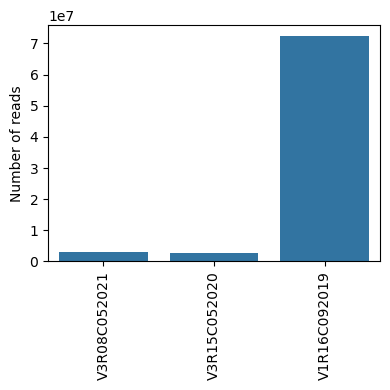

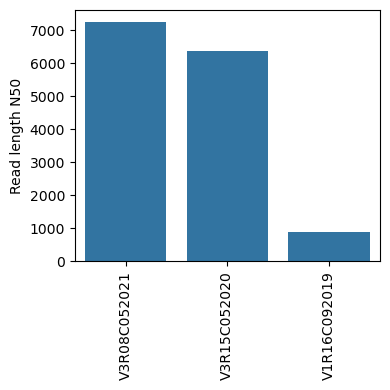

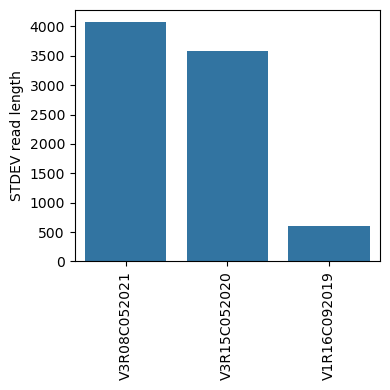

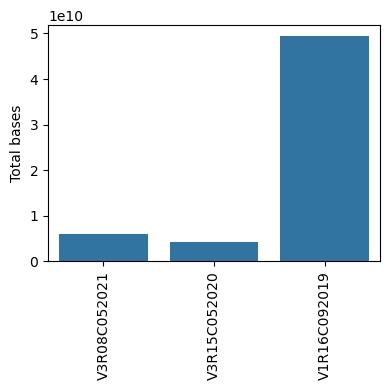

In [26]:
for stat in columns[1:]:

    plt.figure(figsize=(4, 4))
    ax = sns.barplot(data=nanostats_df, x='Barcode', y=stat, order = x_order, legend=False, log_scale=False)
    plt.xticks(rotation=90)
    
    # # Manually add the legend to the right side
    # handles, labels = ax.get_legend_handles_labels()
    # plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(None)
    plt.tight_layout()
    plt.show()

In [29]:
columns = ['Barcode', 'Bee Reads Fraction', 'Bee Bases Fraction']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)
    rows.append((bc, res['reads mapped'] / res['sequences'], res['bases mapped'] / res['total length']))
flagstats_df = pd.DataFrame(rows, columns=columns)
flagstats_df

,Barcode,Bee Reads Fraction,Bee Bases Fraction
0,V3R08C052021,0.523888,0.855070
1,V1R16C092019,0.978751,0.986802
2,V3R15C052020,0.312103,0.653838


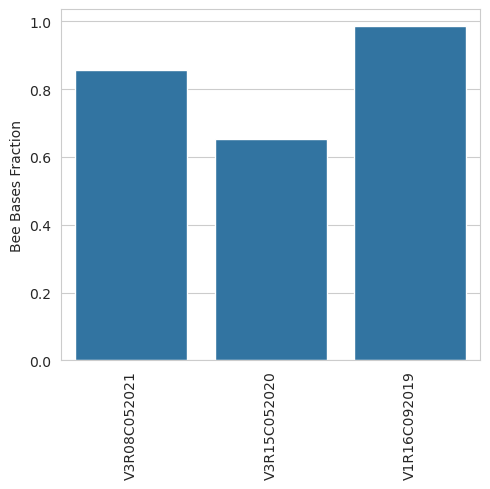

In [38]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=flagstats_df, x='Barcode', y='Bee Bases Fraction', order = x_order, legend=False, log_scale=False)
plt.xticks(rotation=90)

# # Manually add the legend to the right side
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, title='DB', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

In [12]:
columns = ['Barcode', 'Category', 'Mean Read Lengh']
rows = []
for bc in barcode2array_id:
    if not bc: continue
    stats_fn = '{}{}_{}_mapped.stats'.format(minimap2_path, bc, idx_name)
    if not os.path.exists(stats_fn): continue
    res = parse_stats(stats_fn)

    # for mapped reads
    rows.append((bc, 'Mapped', res['bases mapped'] / res['reads mapped']))

    # for unmapped
    rows.append((bc, 'Unmapped', (res['total length'] - res['bases mapped']) / res['reads unmapped']))

stats_df = pd.DataFrame(rows, columns=columns)
stats_df

,Barcode,Category,Mean Read Lengh
0,V3R08C052021,Mapped,3079.110407
1,V3R08C052021,Unmapped,574.264999
2,V1R16C092019,Mapped,688.546963
3,V1R16C092019,Unmapped,424.166468
4,V3R15C052020,Mapped,3297.181723
5,V3R15C052020,Unmapped,792.003340


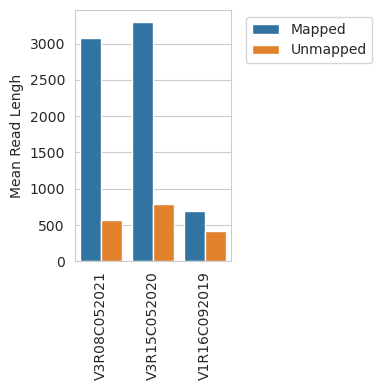

In [15]:
plt.figure(figsize=(4, 4))
ax = sns.barplot(data=stats_df, x='Barcode', y='Mean Read Lengh', hue='Category', order = x_order, legend=True, log_scale=False)
plt.xticks(rotation=90)

# # Manually add the legend to the right side
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(None)
plt.tight_layout()
plt.show()

## taxonomic profiling with Kraken2

In [51]:
kdb_name = 'corent'
read_pool = 'nonbee'
mhg = '2'
cs = '0.05'
# cs = '0.25'
# cs = '0.50'

In [52]:
# get finished pp_ont jobs
step_name = 'pp_ont'
exp_files = [
    '{}BSID_{}_mapped.flagstat'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name), 
    '{}BSID_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
]

completed_jobs_step_before = list(array_id2barcode)
pp_jobs_to_run, pp_completed_jobs = get_jobs_to_restart(step_name, completed_jobs_step_before, array_id2barcode, minimap2_path, exp_files)
pp_jobs_to_run, pp_completed_jobs

([], [1, 2, 3])

In [53]:
k2_jobs_to_run = pp_completed_jobs

In [69]:
step_name = 'kraken2'

k2_exp_files = [
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1.kraken2'.format(kraken2_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1.k2report'.format(kraken2_path, kdb_name, read_pool, mhg, str(cs).replace('.', ''))]
brack_exp_files = [
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_S.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_S.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_F.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_F.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_G.bracken'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
    '{}BSID_{}_{}_mhg{}_cs{}_sf1_rep1_G.breport'.format(bracken_path, kdb_name, read_pool, mhg, str(cs).replace('.', '')), 
]

k2_jobs_to_run, k2_completed_jobs = get_jobs_to_restart(step_name, pp_completed_jobs, array_id2barcode, kraken2_path, k2_exp_files + brack_exp_files)
k2_jobs_to_run, k2_completed_jobs

([], [1, 2, 3])

In [57]:
# most efficient is actually to run things in home 
array_str = write_array_str(k2_jobs_to_run, min(len(k2_jobs_to_run), 3))
kraken2_script = '{}kraken2.run'.format(script_path)
write_kraken2_script(kraken2_script, array_str, read_pool, mhg, cs)
array_str

'1-3%3'

In [59]:
kdb_path, kdb_name, minimap2_path, kraken2_path, bracken_path, bs_ids_file

('/cluster/raid/home/f80878961/data/krakdb/',
 'corent',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/01_preprocessing/minimap2/',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/02_taxonomic_classif/kraken2/',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/02_taxonomic_classif/bracken/',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/00_metadata/bs_ids.txt')

In [60]:
command = ['sbatch', kraken2_script, kdb_path, kdb_name, minimap2_path, kraken2_path, bracken_path, bs_ids_file]
result = subprocess.run(command, cwd=kraken2_path, capture_output=False)

Submitted batch job 1431893


## Assembly

In [65]:
assembly_script = '{}myloasm.run'.format(script_path)
write_myloasm_script(assembly_script)

In [66]:
fastq_fn = '{}all_{}_unmapped.fastq.gz'.format(minimap2_path, idx_name)
fastq_fn

'/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/01_preprocessing/minimap2/all_bee3ref_unmapped.fastq.gz'

In [67]:
assembly_script, fastq_fn, myloasm_path

('/cluster/raid/home/f80878961/scripts/tmp_scripts/myloasm.run',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/01_preprocessing/minimap2/all_bee3ref_unmapped.fastq.gz',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/03_assembly/myloasm/')

In [68]:
command = ['sbatch', assembly_script, fastq_fn, myloasm_path]
result = subprocess.run(command, cwd=myloasm_path, capture_output=False)

Submitted batch job 1431897


### contig taxonomy

In [8]:
contig_kraken2_script = '{}contig_kraken2.run'.format(script_path)
write_contig_kraken2_script(contig_kraken2_script)

In [10]:
contig_fn = '{}assembly_primary.fa'.format(myloasm_path)
out_name = 'ont_myloasm'

In [14]:
contig_kraken2_script, kdb_path, kdb_name, contig_fn, contig_kraken2_path, out_name

('/cluster/raid/home/f80878961/scripts/tmp_scripts/contig_kraken2.run',
 '/cluster/raid/home/f80878961/data/krakdb/',
 'corent',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/03_assembly/myloasm/assembly_primary.fa',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/03_assembly/contig_kraken2/',
 'ont_myloasm')

In [15]:
command = ['sbatch', contig_kraken2_script, kdb_path, kdb_name, contig_fn, contig_kraken2_path, out_name]
result = subprocess.run(command, cwd=contig_kraken2_path, capture_output=False)

Submitted batch job 1431974


### checkm2

mylotools extract-contigs --output-folder contigs_dir --min-contig-length 300000

In [18]:
checkm2_script = '{}checkm2.run'.format(script_path)
write_checkm2_script(checkm2_script)

In [22]:
checkm2_bin = '/cluster/raid/home/f80878961/bin/checkm2/bin/checkm2'
contigs_dir = '{}contigs_dir'.format(myloasm_path)
checkm2_out = '{}ont_myloasm'.format(checkm2_path)

checkm2_db = '/cluster/raid/home/f80878961/bin/checkm2/CheckM2_database/uniref100.KO.1.dmnd'

In [23]:
checkm2_script, checkm2_bin, contigs_dir, checkm2_out, checkm2_db

('/cluster/raid/home/f80878961/scripts/tmp_scripts/checkm2.run',
 '/cluster/raid/home/f80878961/bin/checkm2/bin/checkm2',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/03_assembly/myloasm/contigs_dir',
 '/cluster/raid/home/f80878961/nanopore/2025_Agripol/DNA/03_assembly/checkm2/ont_myloasm',
 '/cluster/raid/home/f80878961/bin/checkm2/CheckM2_database/uniref100.KO.1.dmnd')

In [24]:
command = ['sbatch', checkm2_script, checkm2_bin, contigs_dir, checkm2_out, checkm2_db]
result = subprocess.run(command, cwd=checkm2_path, capture_output=False)

Submitted batch job 1431976


In [25]:
checkm2_df = pd.read_table('{}/quality_report.tsv'.format(checkm2_out))

In [26]:
checkm2_df.sort_values('Max_Contig_Length', ascending=False)

,Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Total_Contigs,Max_Contig_Length,Additional_Notes
11,u247262ctg_len-2546690_circular-yes_depth-8-1-...,99.84,1.26,Neural Network (Specific Model),11,0.810,2546690,288.782245,2546690,0.46,2388,1,2546690,NaN
22,u372748ctg_len-1997497_circular-no_depth-5-2-1...,93.57,3.60,Neural Network (Specific Model),11,0.861,1997497,287.519260,1997497,0.36,1999,1,1997497,NaN
21,u367463ctg_len-1979671_circular-possibly_depth...,99.96,0.41,Neural Network (Specific Model),11,0.867,1979671,290.071320,1979671,0.37,1977,1,1979671,NaN
3,u166710ctg_len-1463760_circular-no_depth-8-1-1...,55.55,1.11,Neural Network (Specific Model),11,0.853,1463760,305.752018,1463760,0.35,1363,1,1463760,NaN
5,u184971ctg_len-1282206_circular-no_depth-5-1-1...,47.54,1.15,Neural Network (Specific Model),11,0.832,1282206,293.601646,1282206,0.45,1215,1,1282206,NaN
29,u466677ctg_len-1186353_circular-no_depth-8-1-1...,74.99,2.01,Neural Network (Specific Model),11,0.886,1186353,316.291892,1186353,0.37,1110,1,1186353,NaN
33,u88685ctg_len-1078814_circular-no_depth-4-1-1_...,50.11,1.71,Neural Network (Specific Model),11,0.845,1078814,277.373636,1078814,0.42,1100,1,1078814,NaN
30,u62770ctg_len-1061326_circular-no_depth-9-1-1_...,35.65,2.08,Neural Network (Specific Model),11,0.841,1061326,304.438202,1061326,0.35,979,1,1061326,NaN
31,u63255ctg_len-1032500_circular-no_depth-19-4-1...,28.41,7.90,Neural Network (Specific Model),11,0.852,1032500,315.833333,1032500,0.34,930,1,1032500,NaN
8,u212432ctg_len-930704_circular-no_depth-4-1-1_...,35.86,0.34,Neural Network (Specific Model),11,0.808,930704,277.789183,930704,0.45,906,1,930704,NaN


In [27]:
k2_df = pd.read_table('{}{}.kraken2'.format(contig_kraken2_path, out_name), header=None)

In [28]:
k2_df = k2_df.rename(columns={1: 'Name', 2: 'TaxID'})[['Name', 'TaxID']]

In [29]:
k2_df['Taxon'] = ncbi.translate_to_names(k2_df['TaxID'])

In [31]:
pd.set_option('display.max_colwidth', None)

In [32]:
contig_qc_df = k2_df.merge(checkm2_df[['Name', 'Completeness', 'Contamination', 'Coding_Density', 'Average_Gene_Length', 'Genome_Size', 'GC_Content', 'Total_Coding_Sequences']], 
            on='Name').sort_values('Genome_Size', ascending=False).reset_index(drop=True)

In [34]:
contig_qc_df[['Taxon', 'Completeness', 'Contamination', 'Genome_Size']]

,Taxon,Completeness,Contamination,Genome_Size
0,Bartonella apihabitans,99.84,1.26,2546690
1,Lactobacillus kullabergensis,93.57,3.60,1997497
2,Lactobacillus helsingborgensis,99.96,0.41,1979671
3,Gilliamella apis,55.55,1.11,1463760
4,Bartonella apihabitans,47.54,1.15,1282206
5,Lactobacillus apis,74.99,2.01,1186353
6,0,50.11,1.71,1078814
7,Frischella perrara,35.65,2.08,1061326
8,Gilliamella apicola,28.41,7.90,1032500
9,Bartonella apihabitans,35.86,0.34,930704


# 2025

In [ ]:
import nbimporter

# start

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm as tqdm
import matplotlib.pyplot as plt
from ete3 import NCBITaxa
import plotly.express as px
ncbi = NCBITaxa(dbfile="/cluster/raid/home/f80878961/data/taxa.sqlite")


In [ ]:
home_path = '/cluster/raid/home/f80878961/'
script_path ='{}scripts/'.format(home_path)
working_path = '/cluster/raid/home/f80878961/beestrong/ont/'
fastq_path = '{}fastq/'.format(working_path)
mm2_path = '{}minimap2/'.format(working_path)
kraken2_path = '{}kraken2/'.format(working_path)
bracken_path = '{}bracken/'.format(working_path)

if not os.path.exists(mm2_path):
    os.mkdir(mm2_path)
if not os.path.exists(fastq_path):
    os.mkdir(fastq_path)
if not os.path.exists(kraken2_path):
    os.mkdir(kraken2_path)
if not os.path.exists(bracken_path):
    os.mkdir(bracken_path)

In [ ]:
metadata_xlsx = '{}ES203_Overview_Sequencing_Runs_New_GridION.xlsx'.format(working_path)

metadata_df = pd.read_excel(metadata_xlsx, sheet_name='Sheet2', engine='openpyxl')
metadata_df.columns = metadata_df.iloc[14]
metadata_df = metadata_df.iloc[15:].reset_index(drop=True)

# list of beestrong sample ids for array job
bs_ids = [x.replace('-', '_') for x in metadata_df['Sample']]
bs_ids_file = '{}bs_ids.txt'.format(working_path)
# with open(bs_ids_file, 'w') as outf:
#     outf.write('\n'.join(bs_ids))

In [ ]:
# # merge files
# for r in tqdm(metadata_df.iterrows()):
#     barcode_nr = r[1]['#']
#     bs_id = r[1]['Sample'].replace('-', '_')
#     with open('{}{}.fastq.gz'.format(fastq_path, bs_id), 'wb') as outf:
#         for fn in glob.glob('{}fastq_pass/barcode{}/*.fastq.gz'.format(working_path, '%02d' % barcode_nr)):
#             with open(fn, 'rb') as inf:
#                 outf.write(inf.read())

# minimap2

TO DO :

- multiQC although I like this nanoplot
- align to bee genome (maybe minimap2 or long-read specific aligner to avoid latter fuss)
- Kraken2 + Bracken (read first on application to long reads) 

In [ ]:
def write_mm2_script_home(script_fn, array_str):
    runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STR
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=30g
#SBATCH --time=24:00:00
#SBATCH --job-name=mm2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
ml minimap2
ml SAMtools

idx_path=$1
fastq_path=$2
mm2_path=$3
bs_ids_file=$4
ref_name=$5

# getting bs_id
bs_id=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${bs_ids_file})
mm2_prefix=${mm2_path}${bs_id}_${ref_name}

fastq=$fastq_path${bs_id}.fastq.gz
ls -lh $fastq

echo "1. minimap2"
minimap2 -t 8 -a -x map-ont ${idx_path} $fastq > ${mm2_prefix}.sam

echo "2. export unmapped reads"
samtools fastq -n -f 4 ${mm2_prefix}.sam > ${mm2_prefix}_unmapped.fastq

echo "3. SAM to BAM"
samtools view -S -b ${mm2_prefix}.sam > ${mm2_prefix}.bam

echo "4. export stats"
samtools stats ${mm2_prefix}.bam | grep ^SN | cut -f 2- > ${mm2_prefix}.stats

echo "5. compress"
gzip -f ${mm2_prefix}_unmapped.fastq
rm -f ${mm2_prefix}.sam

echo DONE""".replace(
    'ARRAY_STR', array_str)
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

In [ ]:
idx_path = "/cluster/raid/home/f80878961/data/minimap2_indexes/bee.mmi"
ref_name = "bee"

In [ ]:
mm2_script_home = '{}mm2_home.run'.format(script_path)
write_mm2_script_home(mm2_script_home, '2-20')

In [ ]:
%%bash -s "$mm2_script_home" "$idx_path" "$fastq_path" "$mm2_path" "$bs_ids_file" "$ref_name"
cd $4
sbatch $1 $2 $3 $4 $5 $6

Map against varroa genome

In [ ]:
idx_path = "/cluster/raid/home/f80878961/data/minimap2_indexes/varroa.mmi"
ref_name = "varroa"
mm2_script_home = '{}mm2_home.run'.format(script_path)
write_mm2_script_home(mm2_script_home, '2-20')

In [ ]:
%%bash -s "$mm2_script_home" "$idx_path" "$fastq_path" "$mm2_path" "$bs_ids_file" "$ref_name"
cd $4
sbatch $1 $2 $3 $4 $5 $6

# Kraken2

In [ ]:
def write_kraken2_script(kraken2_script_fn, array_str):
    kraken2_runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STR
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=400g
#SBATCH --time=02:00:00
#SBATCH --job-name=kraken2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
which kraken2

kdb_path=$1
kdb_name=$2
mm2_path=$3
kraken2_path=$4
bs_ids_file=$5

# getting bs_id
bs_id=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${bs_ids_file})

fastq=${mm2_path}${bs_id}_bee_unmapped.fastq.gz
ls -lh $fastq

out_file_id=${kraken2_path}${bs_id}_nonbee
echo $out_file_id

echo '1. kraken2'
kraken2 --threads 8 --db ${kdb_path}${kdb_name} --confidence 0.05 --gzip-compressed --output ${out_file_id}.kraken2 --report ${out_file_id}.k2report ${fastq}

echo DONE""".replace('ARRAY_STR', array_str)
    with open(kraken2_script_fn, 'w') as outf:
        outf.write(kraken2_runstr)

In [ ]:
# most efficient is actually to run things in home 
kraken2_script = '{}kraken2.run'.format(script_path)
write_kraken2_script(kraken2_script, '2-20')

In [ ]:
shared_data_path = '/cluster/raid/home/f80878961/data/'
kdb_path = '{}krakdb/'.format(shared_data_path)
kdb_name = 'corent'

In [ ]:
%%bash -s "$kraken2_script" "$kdb_path" "$kdb_name" "$mm2_path" "$kraken2_path" "$bs_ids_file"
cd $5
sbatch $1 $2 $3 $4 $5 $6

# Bracken

In [ ]:
def write_bracken_script(kraken2_script_fn, array_str):
    kraken2_runstr="""#!/bin/bash -l
#SBATCH --array=ARRAY_STR
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=20g
#SBATCH --time=01:00:00
#SBATCH --job-name=bracken
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
which bracken

kdb_path=$1
kdb_name=$2
kraken2_path=$3
bracken_path=$4
bs_ids_file=$5

# getting bs_id
bs_id=$(sed -n ${SLURM_ARRAY_TASK_ID}'{p;q}' ${bs_ids_file})
file_id=${bs_id}_nonbee
k2report_fn=${kraken2_path}${file_id}.k2report
bracken_fn=${bracken_path}${file_id}_S.bracken
breport_fn=${bracken_path}${file_id}_S.breport

ls -lh $k2report_fn
echo $bracken_fn
echo $breport_fn

echo '1. bracken'
bracken -d ${kdb_path}${kdb_name} -i $k2report_fn -r 300 -l S -t 10 -o $bracken_fn -w $breport_fn 

echo DONE""".replace('ARRAY_STR', array_str)
    with open(kraken2_script_fn, 'w') as outf:
        outf.write(kraken2_runstr)

In [ ]:
bracken_script = '{}bracken.run'.format(script_path)
write_bracken_script(bracken_script, '3-20')

In [ ]:
%%bash -s "$bracken_script" "$kdb_path" "$kdb_name" "$kraken2_path" "$bracken_path" "$bs_ids_file"
cd $5
sbatch $1 $2 $3 $4 $5 $6

# Varroa abundance

In [ ]:
def get_total_read_nr(mm2_path, bs_id):
    with open('{}{}_bee.stats'.format(mm2_path, bs_id), 'r') as inf:
        return int(inf.readline().split('raw total sequences:')[1].split()[0])

def parse_kreport(kraken_path, bs_id):
    kreport_fn = '{}{}_nonbee.k2report'.format(kraken_path, bs_id)
    if not os.path.exists(kreport_fn): 
        print('missing {}'.format(kreport_fn))
    with open(kreport_fn, 'r') as inf:
        ucseqs_nr = int(inf.readline().split()[1])
        cseqs_nr = int(inf.readline().split()[1])
    return ucseqs_nr, cseqs_nr

def parse_breport(bracken_path, bs_id, level, taxa):
    '''get read numbers for taxa'''
    breport_fn = '{}{}_nonbee_{}.breport'.format(bracken_path, bs_id, level)
    if not os.path.exists(breport_fn): 
        print('missing {}'.format(breport_fn))
    breport_df = pd.read_csv(breport_fn, header=None, sep='\t')
    breport_df[5] = [x.lstrip() for x in breport_df[5].to_list()]
    return breport_df[breport_df[5].isin(taxa)].set_index(5)[1].to_dict()

def get_classified_read_nr(mm2_path, kraken_path, bracken_path, bs_id_str, level):
    '''
    Equals the total number of read in the raw fasta minus the number of unclassified reads by Bracken.
    For a subsample, I multiple the total number of reads by the sampling fraction (similar to subsampling reads before mapping with bowtie2)
    '''
    total_read_nr = get_total_read_nr(mm2_path, bs_id_str)
    kraken_ucread_nr, kraken_cread_nr = parse_kreport(kraken_path, bs_id_str)
    bracken_cread_nr = parse_breport(bracken_path, bs_id_str, level, ['root'])['root']
    bracken_ucread_nr = kraken_cread_nr - bracken_cread_nr
    return total_read_nr - kraken_ucread_nr - bracken_ucread_nr

def get_bracken_df(mm2_path, kraken2_path, bracken_path, bs_id_str, level):
    '''
    parse bracken file
    '''
    # parse bracken output
    bracken_fn = '{}{}_nonbee_{}.bracken'.format(bracken_path, bs_id_str, level)
    if not os.path.exists(bracken_fn): 
        print('missing {}'.format(bracken_fn))
    bracken_df = pd.read_csv(bracken_fn, sep='\t')

    ## calculate original read numbers
    # number of reads classified by kraken2 + bracken AND by bowtie2 --> to calculate relative abundance
    classified_read_nr = get_classified_read_nr(mm2_path, kraken2_path, bracken_path, bs_id_str, level)
    
    # classified reads - non bee reads
    honeybee_read_nr = classified_read_nr - bracken_df[bracken_df['name'] != 'Apis mellifera']['new_est_reads'].sum()

    # recompute relative abundance
    bracken_df['fraction_total_reads'] = bracken_df['new_est_reads'].to_numpy() / classified_read_nr
    
    # calculate Aitchison log ratio
    bracken_df['ratio_honeybee'] = bracken_df['new_est_reads'].to_numpy() / honeybee_read_nr
    bracken_df['log_ratio_honeybee'] = np.log(bracken_df['new_est_reads'].to_numpy() / honeybee_read_nr)
    
    # log ratio of absolute abundances == log ratio of relative abundances
    assert np.all(np.round(bracken_df['log_ratio_honeybee'].to_numpy(), 10) == np.round(np.log(bracken_df['fraction_total_reads'].to_numpy() / (honeybee_read_nr / classified_read_nr)), 10))

    return bracken_df

def get_stat(mm2_path, bs_id, ref_name, stat):
    '''
    bases mapped:
    reads mapped:
    '''
    with open('{}{}_{}.stats'.format(mm2_path, bs_id, ref_name), 'r') as inf:
        l = inf.readline()
        while not l.startswith(stat):
            l = inf.readline()
        return int(l.split(stat)[1].split()[0])

def get_varroa_bee_ratio_ONT(mm2_path, bs_id, stat):
    bee_read_nr = get_stat(mm2_path, bs_id, 'bee', stat)
    varroa_read_nr = get_stat(mm2_path, bs_id, 'varroa', stat)
    return varroa_read_nr / bee_read_nr

In [ ]:
# parse bracken tables
level = 'S'

df_list = []
for bs_id in tqdm(bs_ids):
    df = get_bracken_df(mm2_path, kraken2_path, bracken_path, bs_id, level)
    df = df[['name', 'taxonomy_id', 'fraction_total_reads', 'new_est_reads', 'log_ratio_honeybee', 'ratio_honeybee']]
    df.insert(0, 'Colony', ['{}'.format(bs_id) for i in range(len(df))])
    df_list.append(df)

brack_df = pd.concat(df_list).rename(columns={'name': 'Taxon', 
                                              'taxonomy_id': 'TaxID', 
                                              'fraction_total_reads': 
                                              'Relative abundance', 'new_est_reads': 
                                              'Read number', 'ratio_honeybee': 
                                              'Ratio Honeybee', 'log_ratio_honeybee': 
                                              'Log Ratio Honeybee'}).reset_index().drop(columns=['index'])

brack_df

In [ ]:
get_stat(mm2_path, 'BS18_0167', 'varroa', 'bases mapped:')

In [ ]:
get_stat(mm2_path, 'BS18_0167', 'bee', 'bases mapped:')

In [ ]:
varroa_df = brack_df[brack_df['Taxon']=='Varroa destructor'][['Colony', 'Relative abundance', 'Ratio Honeybee']].rename(columns={
    'Relative abundance': 'Varroa relative abundance (ONT Kraken2)', 'Ratio Honeybee': 'Varroa Honeybee Ratio (ONT Kraken2)'}).merge(
    pheno_df[['Colony', 'Varroa relative abundance', 'v_pho', 'v_mito']].rename(columns={
    'Varroa relative abundance': 'Varroa relative abundance (Illumina Kraken2)', 'v_pho': 'Nr. Varroa/100 bees'}), how='left', on='Colony')

In [ ]:
varroa_df['Varroa Honeybee Ratio (ONT)'] = varroa_df['Colony'].map(lambda x: get_varroa_bee_ratio_ONT(mm2_path, x, 'bases mapped (cigar):'))

In [ ]:
varroa_df

In [ ]:
x = 'Nr. Varroa/100 bees'
y = 'Varroa relative abundance (Illumina Kraken2)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'Nr. Varroa/100 bees'
y = 'Varroa relative abundance (ONT Kraken2)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'Nr. Varroa/100 bees'
y = 'Varroa Ratio Honeybee (ONT Kraken2)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'Nr. Varroa/100 bees'
y = 'v_mito'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'Varroa relative abundance (Illumina Kraken2)'
y = 'Varroa relative abundance (ONT Kraken2)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'v_mito'
y = 'Varroa relative abundance (ONT Kraken2)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

In [ ]:
x = 'Nr. Varroa/100 bees'
y = 'Varroa Honeybee Ratio (ONT)'

print(varroa_df[x].corr(varroa_df[y]))

sns.regplot(data=varroa_df, x=x, y=y)
plt.show()

- I did not apply any filtering / trimming / error correction on ONT reads
- Kraken2 and Bracken not tuned for this dataset (e.g., smaller k-mer size to handle error rate and length parameters of Bracken)
- Not sure if counting at the read level instead of the base/k-mer level is correct for variable length sequences
- I should probably use tools specific to Long reads like BugSeq as Kraken2 and Bracken were designed for short reads
- An attractive option is to simply align to varroa genome for varroa estimation --> somehow not working (neither for ratio of read mapped nor base mapped) maybe why they used mitochondrial genome...
- 

# Distibuton of key taxa

In [ ]:
def get_class_df(bs_ids, level, group_name2taxid, taxonomic_groups, kraken2_path, bracken_path, mm2_path):
    
    tree = ncbi.get_topology(list(group_name2taxid.values()))
    
    columns = ['Colony', 'Category', 'Read number', 'Relative abundance']
    rows = []
    for bs_id in tqdm(bs_ids):
        ucseqs_nr, cseqs_nr = parse_kreport(kraken2_path, bs_id)
        taxa2seqnr = parse_breport(bracken_path, bs_id, level, taxonomic_groups)
        classified_read_nr = get_classified_read_nr(mm2_path, kraken2_path, bracken_path, bs_id, level)
        
        rows.append((bs_id, 'Unclassified', ucseqs_nr))
        rows.append((bs_id, 'Kraken2 only', cseqs_nr - taxa2seqnr['root']))
        
        for taxon in taxonomic_groups:
            name = group2name.get(taxon, taxon)
            node = tree&group_name2taxid[name]
            read_nr = taxa2seqnr.get(taxon, 0) - sum([taxa2seqnr.get(x, 0) for x in get_desc_taxa(node, taxonomic_groups.difference({node.sci_name}))])
            rows.append((bs_id, name, read_nr, read_nr / classified_read_nr))
    
    return pd.DataFrame(data=rows, columns=columns)

In [ ]:
taxonomic_groups = set(('root', 'Viruses','Bacteria', 'Archaea', 'Eukaryota', 'Embryophyta', 'Fungi', 'Metazoa', 'Apidae','Varroidae'))
categories=['Other Root', 'Viruses','Bacteria', 'Archaea','Other Eukaryota','Embryophyta','Fungi','Other Metazoa', 'Varroidae']
group2name = {'root': 'Other Root', 'Eukaryota': 'Other Eukaryota', 'Metazoa': 'Other Metazoa'}
group_name2taxid = {group2name.get(k, k): v[0] for k, v in ncbi.get_name_translator(taxonomic_groups).items()}
cmap = {
    'Unclassified': '#262626',
    'Kraken2 only': '#575757',
    'Other Root': '#949494',
    'Viruses': '#0173b2',
    'Bacteria': '#de8f05',
    'Archaea': '#d55e00',
    'Other Eukaryota': '#029e73',
    'Embryophyta':'#12634c',
    'Apidae': '#75c8b0',
    'Fungi': '#cc78bc',
    'Other Metazoa': '#ca9161',
    'Varroidae': '#ece133'
}

In [ ]:
from bee_metagenomics import get_desc_taxa

In [ ]:
fam_class_df = get_class_df(bs_ids, 'S', group_name2taxid, taxonomic_groups, kraken2_path, bracken_path, mm2_path)

In [ ]:
fam_class_df

In [ ]:
fig = px.bar(fam_class_df[fam_class_df['Category'].isin(categories)], x="Colony", y="Relative abundance", color="Category",
            hover_data=['Category'], barmode = 'stack', color_discrete_map=cmap, category_orders={"Category": categories})
fig.update_layout(
    autosize=False,
    width=1000,
    height=700,
    xaxis={'title': {'font': {'size': 18}}},
    yaxis={'title': {'font': {'size': 18}}},
    legend={'font': {'size': 16}}
)
fig.show()

- try without Bracken (also for Varroa load estimation)
- compare with Illumina
- repeat for new data

# end